In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')


plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = {'H': '#2ecc71', 'M': '#f39c12', 'L': '#e74c3c'}
GENDER_COLORS = {'M': '#3498db', 'F': '#e91e8c'}

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [2]:
df = pd.read_csv("xAPI-Edu-Data.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nGender distribution:")
print(df['gender'].value_counts())
df.head()

Dataset shape: (480, 17)

Class distribution:
Class
M    211
H    142
L    127
Name: count, dtype: int64

Gender distribution:
gender
M    305
F    175
Name: count, dtype: int64


,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [3]:
print("Data types and missing values:")
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'null': df.isna().sum(),
    'unique': df.nunique()
})
print(info_df)

Data types and missing values:
                           dtype  non_null  null  unique
gender                    object       480     0       2
NationalITy               object       480     0      14
PlaceofBirth              object       480     0      14
StageID                   object       480     0       3
GradeID                   object       480     0      10
SectionID                 object       480     0       3
Topic                     object       480     0      12
Semester                  object       480     0       2
Relation                  object       480     0       2
raisedhands                int64       480     0      82
VisITedResources           int64       480     0      89
AnnouncementsView          int64       480     0      88
Discussion                 int64       480     0      90
ParentAnsweringSurvey     object       480     0       2
ParentschoolSatisfaction  object       480     0       2
StudentAbsenceDays        object       480     0       2


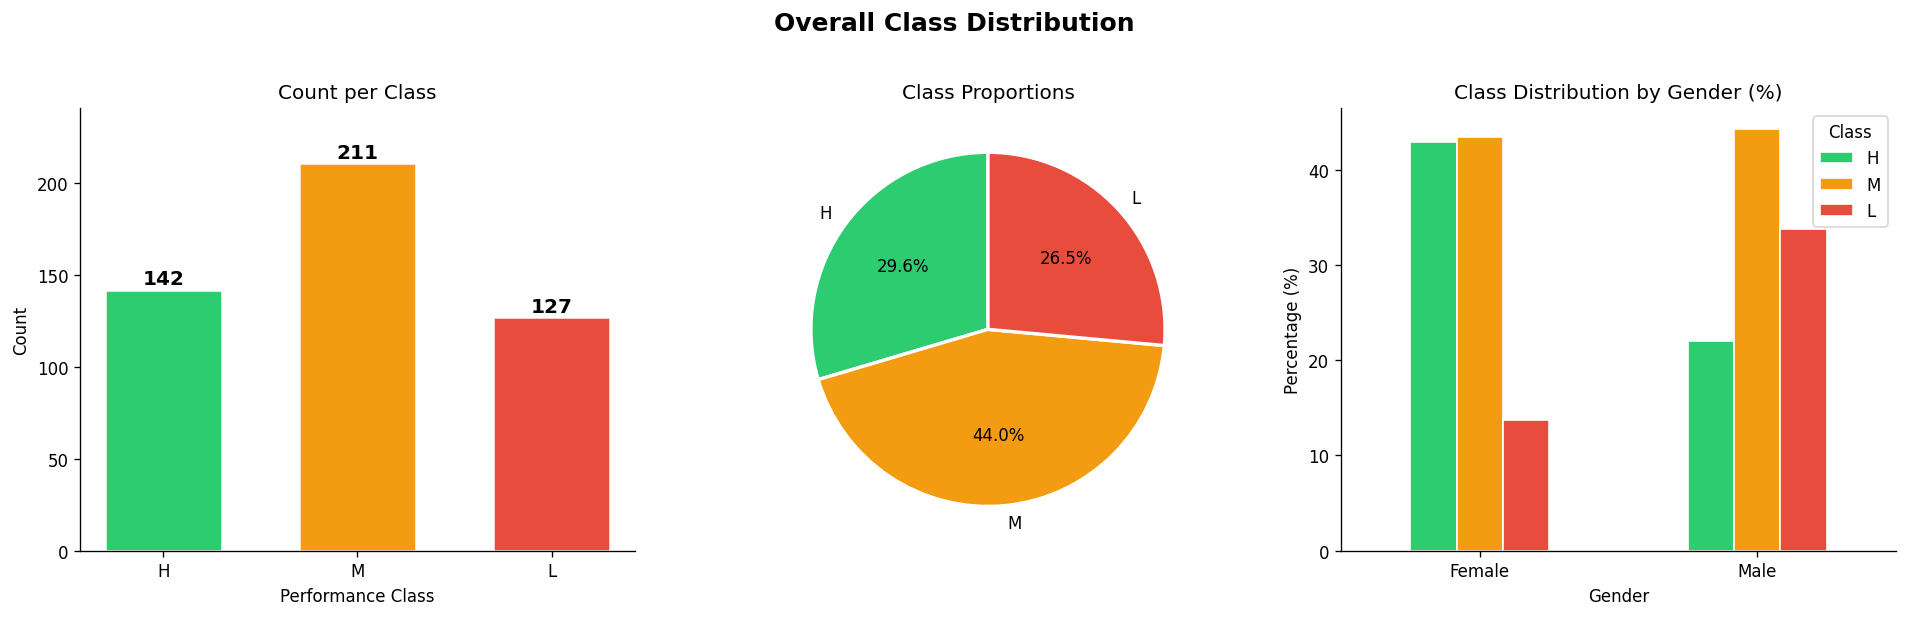


💡 Observation: Check if male and female students have similar class distributions.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Overall Class Distribution', fontsize=15, fontweight='bold', y=1.02)


counts = df['Class'].value_counts().reindex(['H', 'M', 'L'])
bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE[c] for c in counts.index],
                   edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Count per Class')
axes[0].set_xlabel('Performance Class')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() + 30)
axes[0].spines[['top','right']].set_visible(False)


axes[1].pie(counts.values, labels=counts.index,
            colors=[PALETTE[c] for c in counts.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportions')


cross = pd.crosstab(df['gender'], df['Class'])[['H', 'M', 'L']]
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.plot(kind='bar', ax=axes[2],
               color=[PALETTE['H'], PALETTE['M'], PALETTE['L']],
               edgecolor='white', width=0.5)
axes[2].set_title('Class Distribution by Gender (%)')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Percentage (%)')
axes[2].set_xticklabels(['Female', 'Male'], rotation=0)
axes[2].legend(title='Class', loc='upper right')
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()
print("\n💡 Observation: Check if male and female students have similar class distributions.")

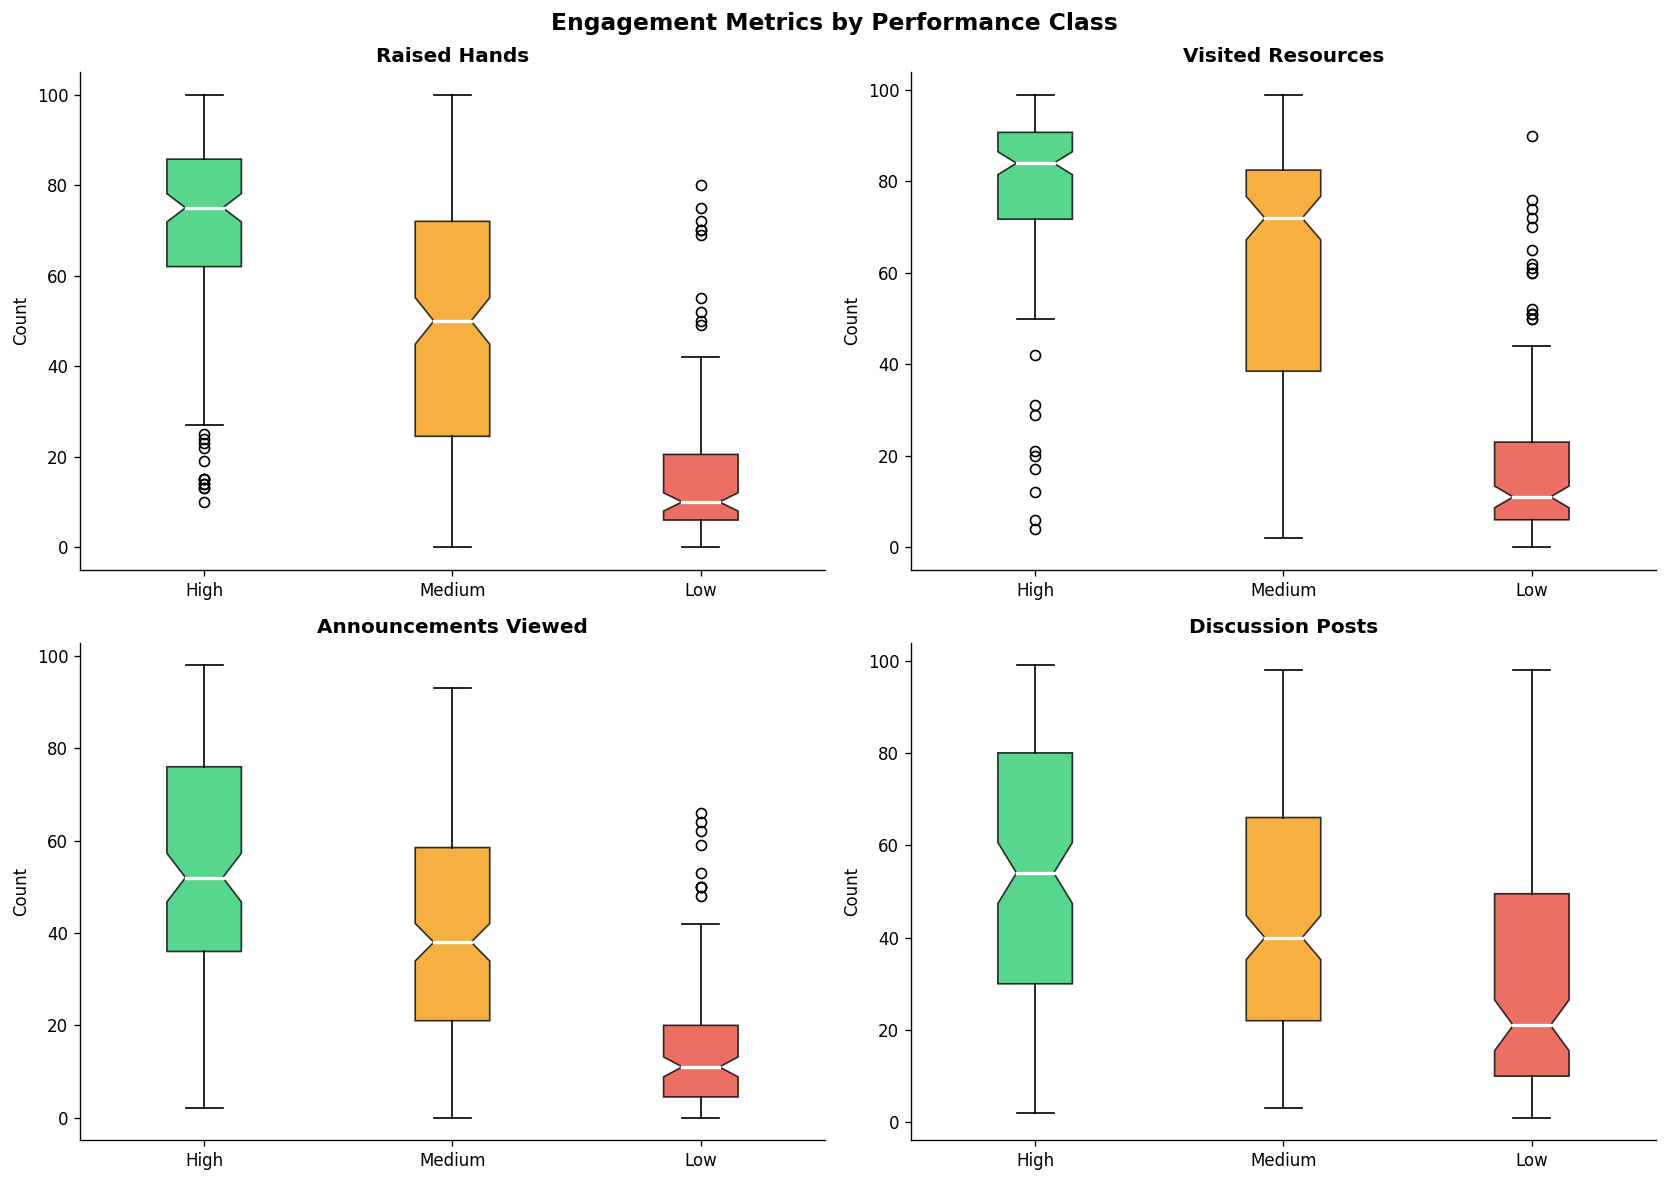


💡 Observation: Higher-performing students consistently show greater engagement across all metrics.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Engagement Metrics by Performance Class', fontsize=14, fontweight='bold')

engagement_cols = ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']
labels = ['Raised Hands', 'Visited Resources', 'Announcements Viewed', 'Discussion Posts']

for ax, col, label in zip(axes.flat, engagement_cols, labels):
    data = [df[df['Class'] == c][col].values for c in ['H', 'M', 'L']]
    bp = ax.boxplot(data, patch_artist=True, notch=True,
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], [PALETTE['H'], PALETTE['M'], PALETTE['L']]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels(['High', 'Medium', 'Low'])
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Count')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig2_engagement_by_class.png', bbox_inches='tight')
plt.show()

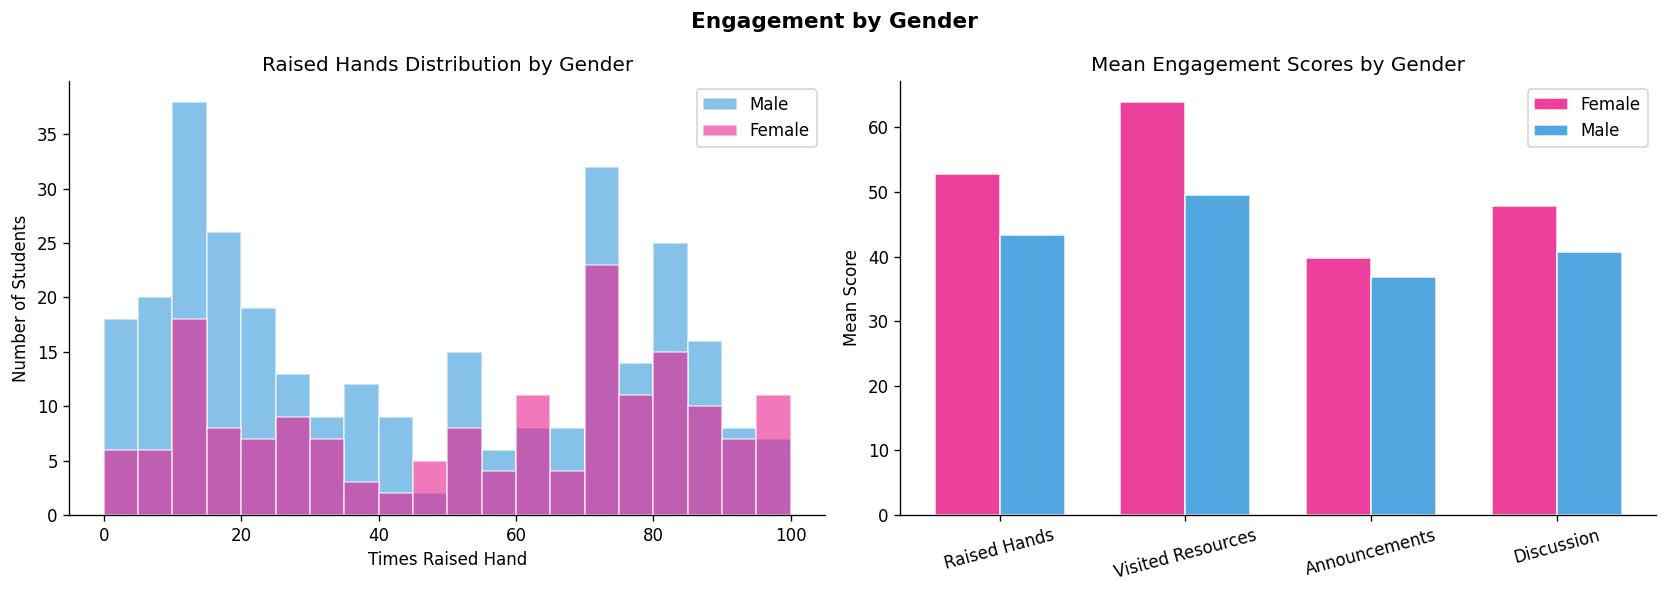


💡 Observation: Are there systematic differences in engagement patterns between genders?


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Engagement by Gender', fontsize=13, fontweight='bold')


for gender, color in GENDER_COLORS.items():
    subset = df[df['gender'] == gender]['raisedhands']
    axes[0].hist(subset, bins=20, alpha=0.6, color=color,
                 label='Male' if gender == 'M' else 'Female', edgecolor='white')
axes[0].set_title('Raised Hands Distribution by Gender')
axes[0].set_xlabel('Times Raised Hand')
axes[0].set_ylabel('Number of Students')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)


gender_means = df.groupby('gender')[engagement_cols].mean().T
x = np.arange(len(gender_means))
width = 0.35
axes[1].bar(x - width/2, gender_means['F'], width, label='Female',
            color=GENDER_COLORS['F'], alpha=0.85, edgecolor='white')
axes[1].bar(x + width/2, gender_means['M'], width, label='Male',
            color=GENDER_COLORS['M'], alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Raised Hands', 'Visited Resources',
                          'Announcements', 'Discussion'], rotation=15)
axes[1].set_title('Mean Engagement Scores by Gender')
axes[1].set_ylabel('Mean Score')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig3_gender_engagement.png', bbox_inches='tight')
plt.show()


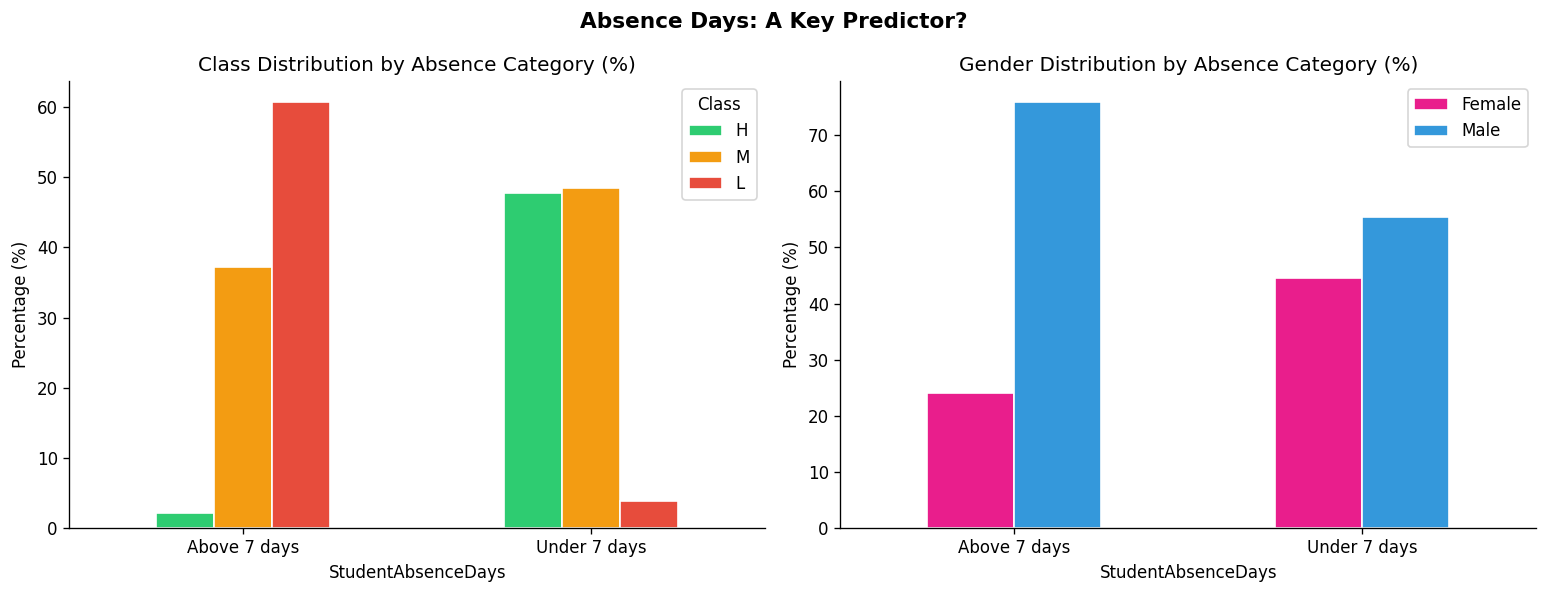


💡 Observation: Absence days strongly correlate with class and may interact with gender.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Absence Days: A Key Predictor?', fontsize=13, fontweight='bold')


abs_class = pd.crosstab(df['StudentAbsenceDays'], df['Class'])[['H','M','L']]
abs_pct = abs_class.div(abs_class.sum(axis=1), axis=0) * 100
abs_pct.plot(kind='bar', ax=axes[0],
             color=[PALETTE['H'], PALETTE['M'], PALETTE['L']],
             edgecolor='white', width=0.5)
axes[0].set_xticklabels(['Above 7 days', 'Under 7 days'], rotation=0)
axes[0].set_title('Class Distribution by Absence Category (%)')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Class')
axes[0].spines[['top','right']].set_visible(False)


abs_gender = pd.crosstab(df['StudentAbsenceDays'], df['gender'])
abs_gender_pct = abs_gender.div(abs_gender.sum(axis=1), axis=0) * 100
abs_gender_pct.plot(kind='bar', ax=axes[1],
                     color=[GENDER_COLORS['F'], GENDER_COLORS['M']],
                     edgecolor='white', width=0.5)
axes[1].set_xticklabels(['Above 7 days', 'Under 7 days'], rotation=0)
axes[1].set_title('Gender Distribution by Absence Category (%)')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['Female', 'Male'])
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_absence.png', bbox_inches='tight')
plt.show()


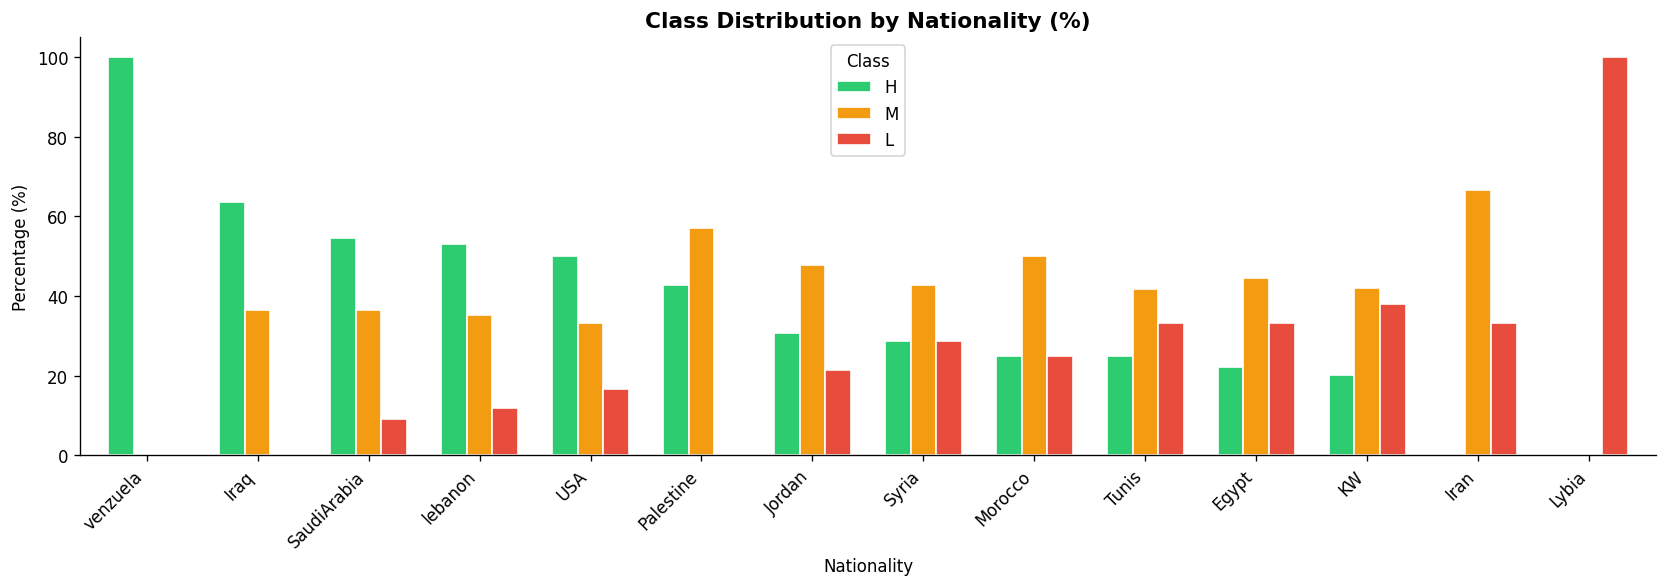


💡 Observation: Performance distributions vary across nationalities — a potential source of bias.


In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

nat_class = pd.crosstab(df['NationalITy'], df['Class'])[['H','M','L']]
nat_pct = nat_class.div(nat_class.sum(axis=1), axis=0) * 100
nat_pct_sorted = nat_pct.sort_values('H', ascending=False)

nat_pct_sorted.plot(kind='bar', ax=ax,
                    color=[PALETTE['H'], PALETTE['M'], PALETTE['L']],
                    edgecolor='white', width=0.7)
ax.set_title('Class Distribution by Nationality (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Nationality')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(nat_pct_sorted.index, rotation=45, ha='right')
ax.legend(title='Class')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig5_nationality.png', bbox_inches='tight')


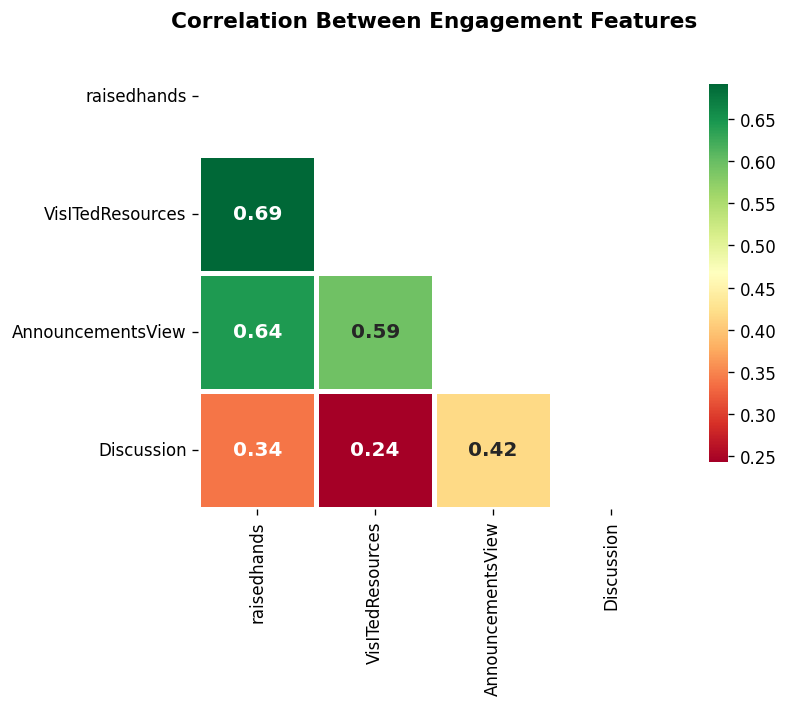


💡 Observation: Features are moderately correlated — no severe multicollinearity.


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

num_cols = ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, square=True, linewidths=2,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Correlation Between Engagement Features', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_correlation.png', bbox_inches='tight')
plt.show()


In [10]:
sensitive_cols = ['gender', 'NationalITy']
target_col = 'Class'
drop_cols = ['PlaceofBirth'] 

feature_cols = [c for c in df.columns if c not in [target_col] + drop_cols]
feature_cols_no_sensitive = [c for c in feature_cols if c not in sensitive_cols]

cat_cols_all = df[feature_cols].select_dtypes(include='object').columns.tolist()
num_cols_all = df[feature_cols].select_dtypes(exclude='object').columns.tolist()

cat_cols_ns = [c for c in cat_cols_all if c not in sensitive_cols]
num_cols_ns = num_cols_all 

X = df[feature_cols]
X_ns = df[feature_cols_no_sensitive]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train_ns = X_train[feature_cols_no_sensitive]
X_test_ns = X_test[feature_cols_no_sensitive]


gender_test = X_test['gender'].values
nationality_test = X_test['NationalITy'].values

print(f"Training size: {len(X_train)} | Test size: {len(X_test)}")
print(f"\nFeatures (full):           {len(feature_cols)}")
print(f"Features (no sensitive):   {len(feature_cols_no_sensitive)}")

Training size: 384 | Test size: 96

Features (full):           15
Features (no sensitive):   13


In [11]:
def build_lr_pipeline(cat_cols, num_cols):
    preprocessor = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ])
    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42, C=1.0))
    ])

def build_dt_pipeline(cat_cols, num_cols):
    preprocessor = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ])
    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))
    ])


lr_full = build_lr_pipeline(cat_cols_all, num_cols_all)
lr_full.fit(X_train, y_train)

lr_ns = build_lr_pipeline(cat_cols_ns, num_cols_ns)
lr_ns.fit(X_train_ns, y_train)

dt_full = build_dt_pipeline(cat_cols_all, num_cols_all)
dt_full.fit(X_train, y_train)

dt_ns = build_dt_pipeline(cat_cols_ns, num_cols_ns)
dt_ns.fit(X_train_ns, y_train)

models = {
    'LR (full)':       (lr_full,  X_test),
    'LR (no sensitive)': (lr_ns,  X_test_ns),
    'DT (full)':       (dt_full,  X_test),
    'DT (no sensitive)': (dt_ns,  X_test_ns),
}

print("✅ All models trained.")
for name, (model, X_t) in models.items():
    acc = accuracy_score(y_test, model.predict(X_t))
    print(f"  {name}: Accuracy = {acc:.3f}")

✅ All models trained.
  LR (full): Accuracy = 0.719
  LR (no sensitive): Accuracy = 0.729
  DT (full): Accuracy = 0.688
  DT (no sensitive): Accuracy = 0.656


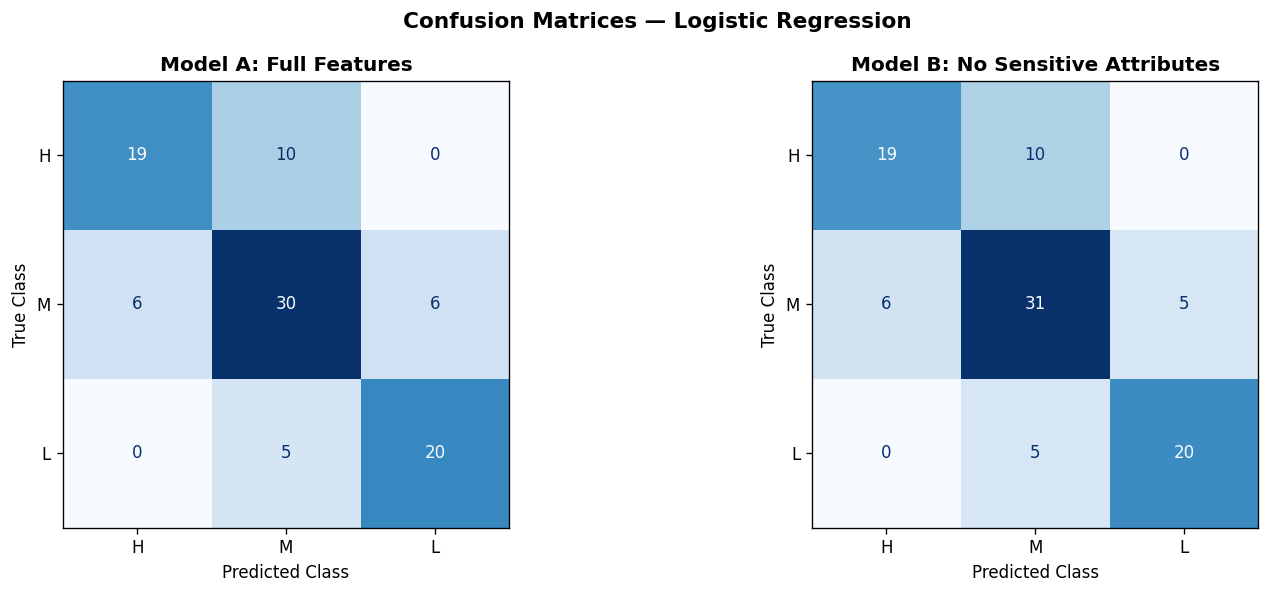

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrices — Logistic Regression', fontsize=13, fontweight='bold')

classes = ['H', 'M', 'L']
titles = ['Model A: Full Features', 'Model B: No Sensitive Attributes']

for ax, (name, (model, X_t)), title in zip(
        axes, [('LR (full)', (lr_full, X_test)), ('LR (no sensitive)', (lr_ns, X_test_ns))],
        titles):
    y_pred = model.predict(X_t)
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('True Class')

plt.tight_layout()
plt.savefig('fig7_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [13]:
print("=" * 50)
print("Classification Report: Logistic Regression (Full)")
print("=" * 50)
print(classification_report(y_test, lr_full.predict(X_test)))

print("=" * 50)
print("Classification Report: Decision Tree (Full)")
print("=" * 50)
print(classification_report(y_test, dt_full.predict(X_test)))

Classification Report: Logistic Regression (Full)
              precision    recall  f1-score   support

           H       0.76      0.66      0.70        29
           L       0.77      0.80      0.78        25
           M       0.67      0.71      0.69        42

    accuracy                           0.72        96
   macro avg       0.73      0.72      0.73        96
weighted avg       0.72      0.72      0.72        96

Classification Report: Decision Tree (Full)
              precision    recall  f1-score   support

           H       0.70      0.66      0.68        29
           L       0.72      0.84      0.78        25
           M       0.65      0.62      0.63        42

    accuracy                           0.69        96
   macro avg       0.69      0.70      0.70        96
weighted avg       0.69      0.69      0.68        96



In [14]:
def demographic_parity(y_pred, groups, positive_class='H'):
    """Positive prediction rate per group."""
    results = {}
    for g in np.unique(groups):
        mask = groups == g
        rate = np.mean(y_pred[mask] == positive_class)
        results[g] = round(rate, 4)
    return results

def equal_opportunity(y_true, y_pred, groups, positive_class='H'):
    """True Positive Rate per group (among truly positive instances)."""
    results = {}
    for g in np.unique(groups):
        mask = (groups == g) & (np.array(y_true) == positive_class)
        if mask.sum() == 0:
            results[g] = None
        else:
            tpr = np.mean(np.array(y_pred)[mask] == positive_class)
            results[g] = round(tpr, 4)
    return results

def fairness_gap(metric_dict):
    """Max difference between groups — the fairness gap."""
    vals = [v for v in metric_dict.values() if v is not None]
    return round(max(vals) - min(vals), 4)


✅ Fairness functions defined.


In [15]:
y_test_arr = np.array(y_test)


preds = {
    'LR Full':      lr_full.predict(X_test),
    'LR No Sens.':  lr_ns.predict(X_test_ns),
    'DT Full':      dt_full.predict(X_test),
    'DT No Sens.':  dt_ns.predict(X_test_ns),
}

print("=" * 60)
print("FAIRNESS ANALYSIS BY GENDER (Positive class = 'H' / High)")
print("=" * 60)

fair_summary = []
for name, y_pred in preds.items():
    dp = demographic_parity(y_pred, gender_test)
    eo = equal_opportunity(y_test_arr, y_pred, gender_test)
    dp_gap = fairness_gap(dp)
    eo_gap = fairness_gap({k: v for k, v in eo.items() if v is not None})
    acc = accuracy_score(y_test_arr, y_pred)
    fair_summary.append({
        'Model': name,
        'Accuracy': round(acc, 3),
        'DP (F)': dp.get('F', '—'),
        'DP (M)': dp.get('M', '—'),
        'DP Gap': dp_gap,
        'EO (F)': eo.get('F', '—'),
        'EO (M)': eo.get('M', '—'),
        'EO Gap': eo_gap,
    })
    print(f"\n📊 {name}")
    print(f"   Accuracy: {acc:.3f}")
    print(f"   Demographic Parity: Female={dp.get('F')}, Male={dp.get('M')} | Gap={dp_gap}")
    print(f"   Equal Opportunity:  Female={eo.get('F')}, Male={eo.get('M')} | Gap={eo_gap}")

fair_df = pd.DataFrame(fair_summary)
print("\n")
fair_df

FAIRNESS ANALYSIS BY GENDER (Positive class = 'H' / High)

📊 LR Full
   Accuracy: 0.719
   Demographic Parity: Female=0.4103, Male=0.1579 | Gap=0.2524
   Equal Opportunity:  Female=0.6667, Male=0.6364 | Gap=0.0303

📊 LR No Sens.
   Accuracy: 0.729
   Demographic Parity: Female=0.3846, Male=0.1754 | Gap=0.2092
   Equal Opportunity:  Female=0.6111, Male=0.7273 | Gap=0.1162

📊 DT Full
   Accuracy: 0.688
   Demographic Parity: Female=0.4359, Male=0.1754 | Gap=0.2605
   Equal Opportunity:  Female=0.7222, Male=0.5455 | Gap=0.1767

📊 DT No Sens.
   Accuracy: 0.656
   Demographic Parity: Female=0.2821, Male=0.1579 | Gap=0.1242
   Equal Opportunity:  Female=0.5, Male=0.5455 | Gap=0.0455




,Model,Accuracy,DP (F),DP (M),DP Gap,EO (F),EO (M),EO Gap
0,LR Full,0.719,0.4103,0.1579,0.2524,0.6667,0.6364,0.0303
1,LR No Sens.,0.729,0.3846,0.1754,0.2092,0.6111,0.7273,0.1162
2,DT Full,0.688,0.4359,0.1754,0.2605,0.7222,0.5455,0.1767
3,DT No Sens.,0.656,0.2821,0.1579,0.1242,0.5000,0.5455,0.0455


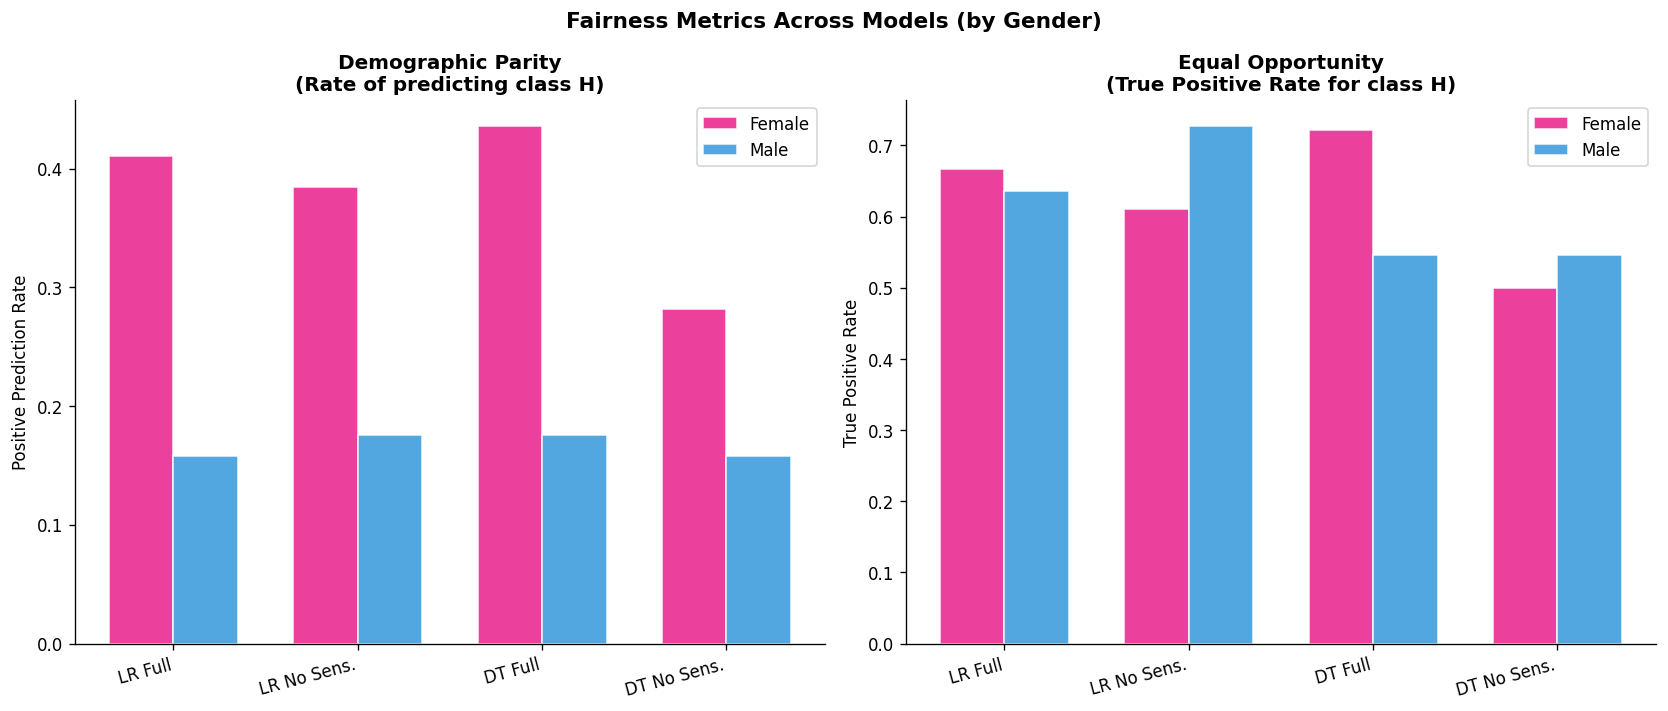


💡 Closer bars = fairer model. Note the gap differences across models.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Fairness Metrics Across Models (by Gender)', fontsize=13, fontweight='bold')

model_names = fair_df['Model']
x = np.arange(len(model_names))
width = 0.35


axes[0].bar(x - width/2, fair_df['DP (F)'], width, label='Female',
            color=GENDER_COLORS['F'], alpha=0.85, edgecolor='white')
axes[0].bar(x + width/2, fair_df['DP (M)'], width, label='Male',
            color=GENDER_COLORS['M'], alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_title('Demographic Parity\n(Rate of predicting class H)', fontweight='bold')
axes[0].set_ylabel('Positive Prediction Rate')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)


axes[1].bar(x - width/2, fair_df['EO (F)'], width, label='Female',
            color=GENDER_COLORS['F'], alpha=0.85, edgecolor='white')
axes[1].bar(x + width/2, fair_df['EO (M)'], width, label='Male',
            color=GENDER_COLORS['M'], alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=15, ha='right')
axes[1].set_title('Equal Opportunity\n(True Positive Rate for class H)', fontweight='bold')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig8_fairness_gender.png', bbox_inches='tight')
plt.show()


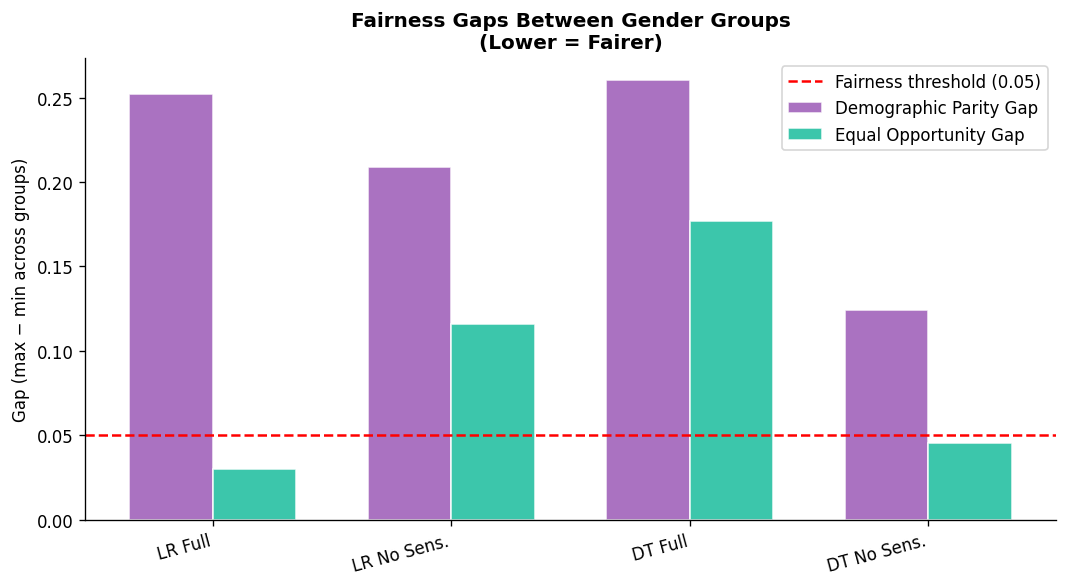


💡 Red dashed line = commonly used 5% fairness threshold.


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(fair_df))
width = 0.35

bars1 = ax.bar(x - width/2, fair_df['DP Gap'], width, label='Demographic Parity Gap',
               color='#9b59b6', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, fair_df['EO Gap'], width, label='Equal Opportunity Gap',
               color='#1abc9c', alpha=0.85, edgecolor='white')

ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='Fairness threshold (0.05)')
ax.set_xticks(x)
ax.set_xticklabels(fair_df['Model'], rotation=15, ha='right')
ax.set_title('Fairness Gaps Between Gender Groups\n(Lower = Fairer)', fontsize=12, fontweight='bold')
ax.set_ylabel('Gap (max − min across groups)')
ax.legend()
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig9_fairness_gaps.png', bbox_inches='tight')
plt.show()

In [18]:
train_data = X_train.copy()
train_data['Class'] = y_train.values


print("Class × Gender counts in training set:")
print(pd.crosstab(train_data['Class'], train_data['gender']))


max_count = train_data.groupby(['Class', 'gender']).size().max()

balanced_parts = []
for (cls, gen), group in train_data.groupby(['Class', 'gender']):
    if len(group) < max_count:
        oversampled = resample(group, replace=True, n_samples=max_count, random_state=42)
        balanced_parts.append(oversampled)
    else:
        balanced_parts.append(group)

train_balanced = pd.concat(balanced_parts).sample(frac=1, random_state=42)
X_train_bal = train_balanced.drop('Class', axis=1)
y_train_bal = train_balanced['Class']

print(f"\nOriginal training size:  {len(X_train)}")
print(f"Balanced training size:  {len(X_train_bal)}")
print("\nClass × Gender after balancing:")
print(pd.crosstab(y_train_bal, X_train_bal['gender']))

Class × Gender counts in training set:
gender   F    M
Class          
H       57   56
L       20   82
M       59  110

Original training size:  384
Balanced training size:  660

Class × Gender after balancing:
gender    F    M
Class           
H       110  110
L       110  110
M       110  110


In [19]:
X_train_bal_ns = X_train_bal[feature_cols_no_sensitive]

lr_mitigated = build_lr_pipeline(cat_cols_ns, num_cols_ns)
lr_mitigated.fit(X_train_bal_ns, y_train_bal)

y_pred_mitigated = lr_mitigated.predict(X_test_ns)

print("Mitigated Model (LR, no sensitive, balanced):")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_mitigated):.3f}")

dp_m = demographic_parity(y_pred_mitigated, gender_test)
eo_m = equal_opportunity(y_test_arr, y_pred_mitigated, gender_test)
print(f"  DP:  Female={dp_m['F']}, Male={dp_m['M']} | Gap={fairness_gap(dp_m)}")
print(f"  EO:  Female={eo_m['F']}, Male={eo_m['M']} | Gap={fairness_gap({k:v for k,v in eo_m.items() if v})}")

Mitigated Model (LR, no sensitive, balanced):
  Accuracy: 0.729
  DP:  Female=0.4872, Male=0.2456 | Gap=0.2416
  EO:  Female=0.8333, Male=0.7273 | Gap=0.106


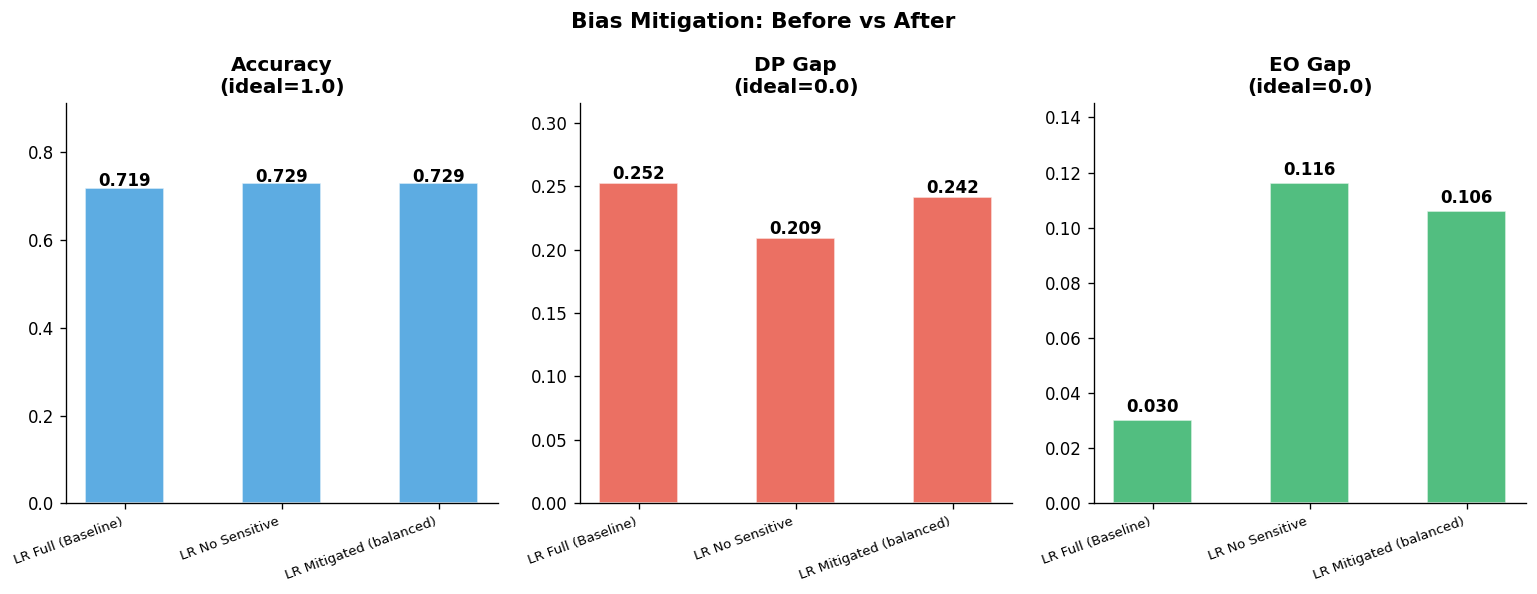

                  Model  Accuracy  DP Gap  EO Gap
     LR Full (Baseline)  0.718750  0.2524  0.0303
        LR No Sensitive  0.729167  0.2092  0.1162
LR Mitigated (balanced)  0.729167  0.2416  0.1060

💡 Note: Removing sensitive attributes and balancing the dataset can reduce fairness gaps,
   sometimes at a small cost to overall accuracy — the classic fairness-accuracy trade-off.


In [20]:
comparison = pd.DataFrame([
    {
        'Model': 'LR Full (Baseline)',
        'Accuracy': accuracy_score(y_test, preds['LR Full']),
        'DP Gap': fairness_gap(demographic_parity(preds['LR Full'], gender_test)),
        'EO Gap': fairness_gap({k:v for k,v in equal_opportunity(y_test_arr, preds['LR Full'], gender_test).items() if v}),
    },
    {
        'Model': 'LR No Sensitive',
        'Accuracy': accuracy_score(y_test, preds['LR No Sens.']),
        'DP Gap': fairness_gap(demographic_parity(preds['LR No Sens.'], gender_test)),
        'EO Gap': fairness_gap({k:v for k,v in equal_opportunity(y_test_arr, preds['LR No Sens.'], gender_test).items() if v}),
    },
    {
        'Model': 'LR Mitigated (balanced)',
        'Accuracy': accuracy_score(y_test, y_pred_mitigated),
        'DP Gap': fairness_gap(dp_m),
        'EO Gap': fairness_gap({k:v for k,v in eo_m.items() if v}),
    },
])

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Bias Mitigation: Before vs After', fontsize=13, fontweight='bold')

metrics = ['Accuracy', 'DP Gap', 'EO Gap']
bar_colors = ['#3498db', '#e74c3c', '#27ae60']
ideal = {'Accuracy': 1.0, 'DP Gap': 0.0, 'EO Gap': 0.0}

for ax, metric, color in zip(axes, metrics, bar_colors):
    bars = ax.bar(comparison['Model'], comparison[metric],
                  color=color, alpha=0.8, edgecolor='white', width=0.5)
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'{metric}\n(ideal={ideal[metric]})', fontweight='bold')
    ax.set_xticklabels(comparison['Model'], rotation=20, ha='right', fontsize=8)
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylim(0, comparison[metric].max() * 1.25)

plt.tight_layout()
plt.savefig('fig10_mitigation.png', bbox_inches='tight')
plt.show()

print(comparison.to_string(index=False))


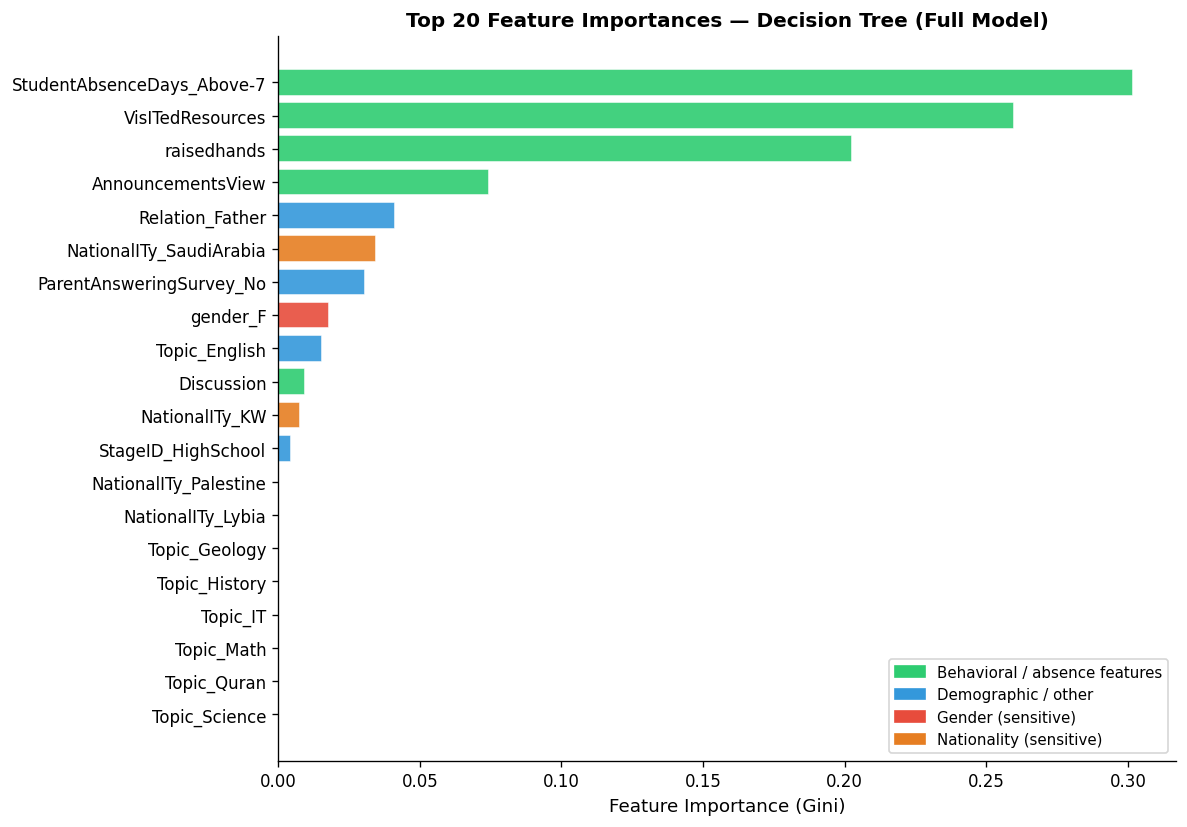


💡 Red/orange bars = sensitive attributes. Even if they rank low, their inclusion can propagate bias.


In [21]:
preprocessor_full = dt_full.named_steps['preprocessor']
cat_feature_names = preprocessor_full.named_transformers_['cat'].get_feature_names_out(cat_cols_all)
all_feature_names = list(cat_feature_names) + num_cols_all

importances = dt_full.named_steps['classifier'].feature_importances_
importance_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))

colors = []
for f in importance_df['feature']:
    if 'gender' in f:
        colors.append('#e74c3c')
    elif 'NationalITy' in f or 'nationality' in f.lower():
        colors.append('#e67e22')
    elif any(s in f for s in ['raisedhands', 'VisITed', 'Announcements', 'Discussion', 'Absence']):
        colors.append('#2ecc71')
    else:
        colors.append('#3498db')

bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color=colors, edgecolor='white', alpha=0.9)
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Top 20 Feature Importances — Decision Tree (Full Model)',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.spines[['top','right']].set_visible(False)

legend_elements = [
    mpatches.Patch(color='#2ecc71', label='Behavioral / absence features'),
    mpatches.Patch(color='#3498db', label='Demographic / other'),
    mpatches.Patch(color='#e74c3c', label='Gender (sensitive)'),
    mpatches.Patch(color='#e67e22', label='Nationality (sensitive)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('fig11_feature_importance.png', bbox_inches='tight')
plt.show()

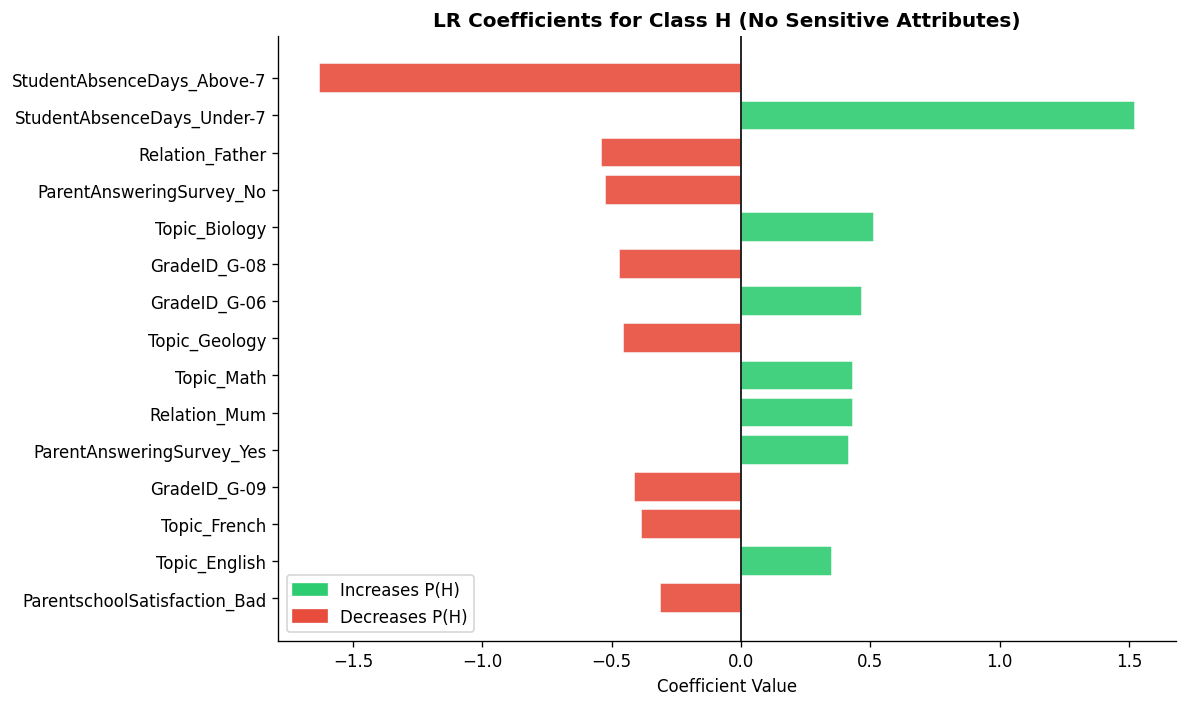


💡 Features with large positive coefficients strongly push predictions toward 'High' performance.


In [22]:
preprocessor_ns = lr_ns.named_steps['preprocessor']
cat_names_ns = preprocessor_ns.named_transformers_['cat'].get_feature_names_out(cat_cols_ns)
all_names_ns = list(cat_names_ns) + num_cols_ns

lr_clf = lr_ns.named_steps['classifier']
classes_order = list(lr_clf.classes_)

h_idx = classes_order.index('H')
coefs = lr_clf.coef_[h_idx]
coef_df = pd.DataFrame({'feature': all_names_ns, 'coef': coefs})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['coef']]
ax.barh(coef_df['feature'], coef_df['coef'], color=bar_colors, edgecolor='white', alpha=0.9)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('LR Coefficients for Class H (No Sensitive Attributes)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()
ax.spines[['top','right']].set_visible(False)

green_patch = mpatches.Patch(color='#2ecc71', label='Increases P(H)')
red_patch = mpatches.Patch(color='#e74c3c', label='Decreases P(H)')
ax.legend(handles=[green_patch, red_patch])

plt.tight_layout()
plt.savefig('fig12_lr_coefficients.png', bbox_inches='tight')
plt.show()


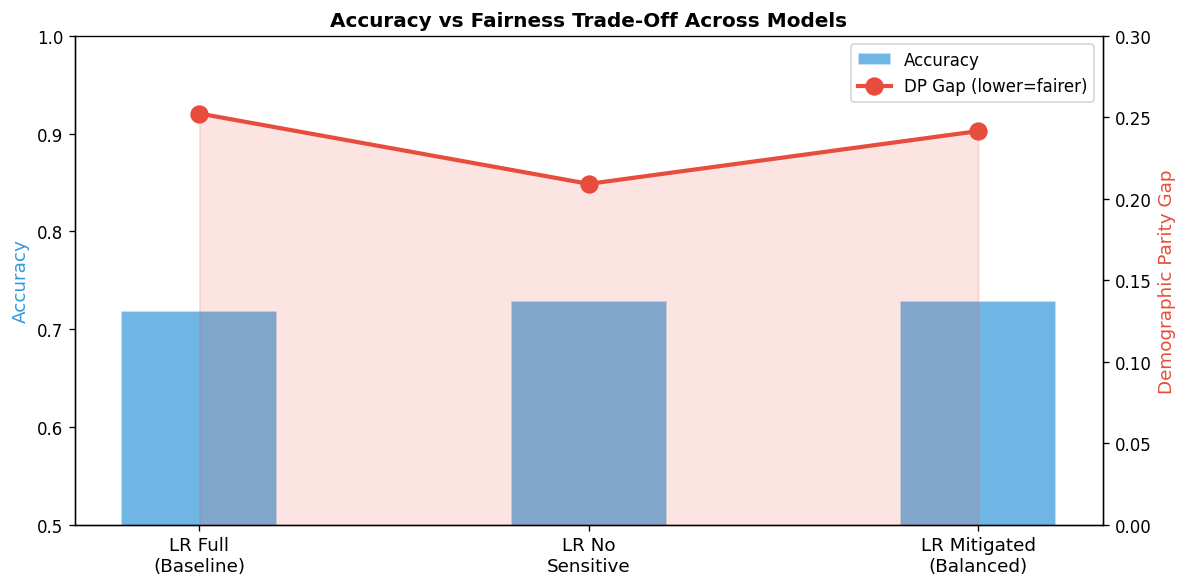


✅ Analysis complete. Bias mitigation reduces the fairness gap with minimal accuracy cost.


In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

model_labels = ['LR Full\n(Baseline)', 'LR No\nSensitive', 'LR Mitigated\n(Balanced)']
accuracies   = [accuracy_score(y_test, preds['LR Full']),
                accuracy_score(y_test, preds['LR No Sens.']),
                accuracy_score(y_test, y_pred_mitigated)]

dp_gaps = [
    fairness_gap(demographic_parity(preds['LR Full'], gender_test)),
    fairness_gap(demographic_parity(preds['LR No Sens.'], gender_test)),
    fairness_gap(dp_m),
]

x = np.arange(len(model_labels))
ax2 = ax.twinx()

bars = ax.bar(x, accuracies, width=0.4, color='#3498db', alpha=0.7,
              label='Accuracy', edgecolor='white')
line = ax2.plot(x, dp_gaps, 'o-', color='#e74c3c', linewidth=2.5,
                markersize=10, label='DP Gap (lower=fairer)')
ax2.fill_between(x, dp_gaps, alpha=0.15, color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_ylabel('Accuracy', color='#3498db', fontsize=11)
ax2.set_ylabel('Demographic Parity Gap', color='#e74c3c', fontsize=11)
ax.set_ylim(0.5, 1.0)
ax2.set_ylim(0, 0.3)

ax.set_title('Accuracy vs Fairness Trade-Off Across Models',
             fontsize=12, fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax.spines[['top']].set_visible(False)

plt.tight_layout()
plt.savefig('fig13_accuracy_fairness_tradeoff.png', bbox_inches='tight')
plt.show()